# E-commerce Funnel & Core Metrics Analysis

## Overview
This notebook analyzes the customer journey from order placement to delivery, identifying drop-off points in the conversion funnel. It also calculates key financial metrics such as Total Revenue and Average Order Value (AOV), and visualizes daily revenue trends to spot seasonality or growth patterns.

## Objectives
1.  **Conversion Funnel:** Visualize the conversion rate between Order Placed, Approved, and Delivered stages.
2.  **Core Metrics:** Calculate Total Revenue and AOV for delivered orders.
3.  **Revenue Trend:** Analyze daily revenue fluctuations over time.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

In [2]:
# Connect to the SQLite database
conn = sqlite3.connect('olist.db')

## 1. Conversion Funnel Analysis
We define the funnel stages as:
1.  **Order Placed:** All orders in the system.
2.  **Order Approved:** Orders that have a payment approval timestamp.
3.  **Order Delivered:** Orders that have been successfully delivered to the customer.

In [3]:
funnel_query = """
SELECT 
    '1. Order Placed' as stage,
    COUNT(order_id) as count
FROM orders

UNION ALL

SELECT 
    '2. Order Approved' as stage,
    COUNT(order_id) as count
FROM orders
WHERE order_approved_at IS NOT NULL

UNION ALL

SELECT 
    '3. Order Delivered' as stage,
    COUNT(order_id) as count
FROM orders
WHERE order_status = 'delivered';
"""

df_funnel = pd.read_sql(funnel_query, conn)

# Calculate conversion rate relative to the first stage
df_funnel['conversion_rate'] = df_funnel['count'] / df_funnel['count'].iloc[0] * 100
display(df_funnel)

,stage,count,conversion_rate
0,1. Order Placed,99441,100.000000
1,2. Order Approved,99281,99.839101
2,3. Order Delivered,96478,97.020344


In [4]:
fig = px.funnel(df_funnel, x='count', y='stage', title='E-commerce Conversion Funnel')
fig.update_layout(title_x=0.5)
fig.show()

## 2. Revenue & Average Order Value (AOV)
We calculate the total revenue generated from delivered orders and the average value of each order.

In [5]:
revenue_query = """
SELECT 
    COUNT(DISTINCT o.order_id) as total_orders,
    SUM(oi.price) as total_revenue,
    SUM(oi.price) / COUNT(DISTINCT o.order_id) as aov
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered';
"""

df_revenue = pd.read_sql(revenue_query, conn)

# Format for display
print(f"Total Delivered Orders: {df_revenue['total_orders'][0]:,}")
print(f"Total Revenue: ${df_revenue['total_revenue'][0]:,.2f}")
print(f"Average Order Value (AOV): ${df_revenue['aov'][0]:,.2f}")

display(df_revenue)

Total Delivered Orders: 96,478
Total Revenue: $13,221,498.11
Average Order Value (AOV): $137.04


,total_orders,total_revenue,aov
0,96478,13221498.11,137.041586


## 3. Daily Revenue Trend
Visualizing how revenue changes day by day to identify trends, spikes, or seasonality.

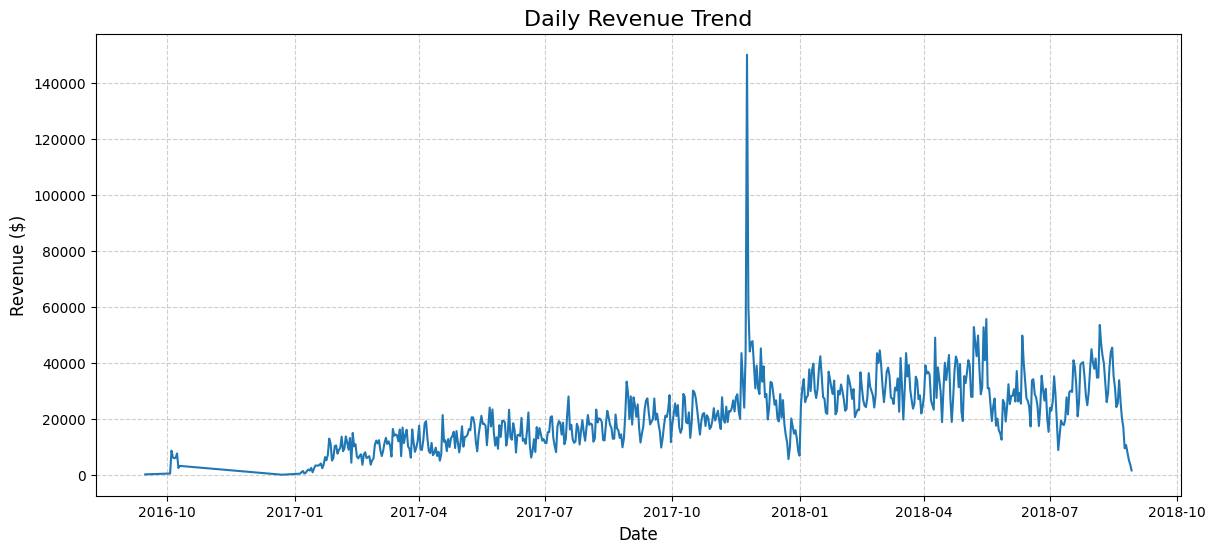

In [6]:
trend_query = """
SELECT 
    DATE(o.order_purchase_timestamp) as date,
    SUM(oi.price) as daily_revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY 1;
"""

df_trend = pd.read_sql(trend_query, conn)
df_trend['date'] = pd.to_datetime(df_trend['date'])

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='date', y='daily_revenue')
plt.title('Daily Revenue Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()